# Poland Macroeconomic Time Series Analysis

## Reference Paper: 
This project is based on the following academic study: 
"Interactions between Output, Inflation, Interest Rates and House Prices: International Evidence".

We reproduce the VAR (Vector Autoregression) methodology from this paper and apply it to Poland's macroeconomic data.

**Reference Link:**
[Access the paper here]
https://www.tandfonline.com/doi/abs/10.1080/09599916.2010.499015

## Objective
To analyze the relationship between:
- Inflation
- Interest Rates
- Housing Prices



## Load Data


The Housing Price Index is converted into its natural logarithm. This transformation helps stabilize variance and interpret changes as approximate percentage growth.

In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("./data/processed/final_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df['ln_housing_price'] = np.log(df['housing_price'])

df.head()

,inflation,interest_rate,housing_price,ln_housing_price
date,,,,
2010-01-01,3.400000,4.146667,104.60,4.650144
2010-04-01,2.400000,3.863333,105.87,4.662212
2010-07-01,2.100000,3.823333,106.02,4.663628
2010-10-01,2.733333,3.893333,105.95,4.662967
2011-01-01,3.633333,4.146667,105.88,4.662306


### Exploratory Analysis

#### Plot data


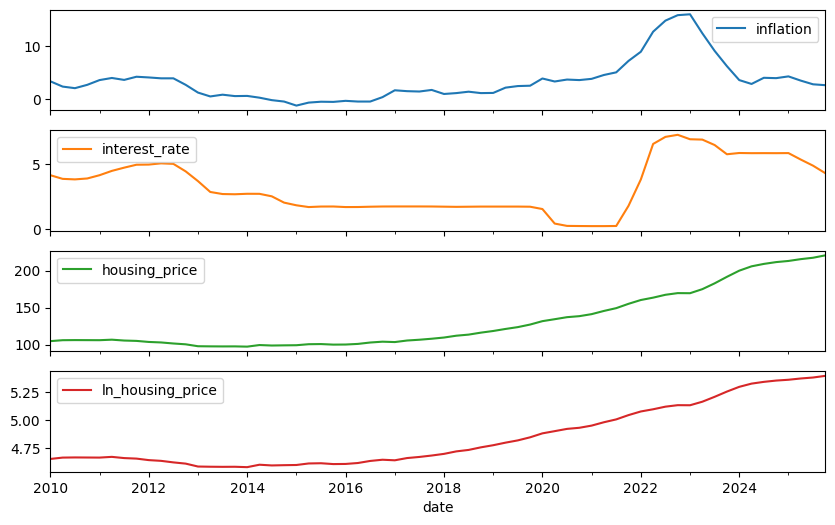

In [18]:
import matplotlib.pyplot as plt

df.plot(subplots=True, figsize=(10,6))
plt.show()

### Interpretation

The three variables clearly show how key parts of the economy are connected and influence each other over time.

- Inflation remained relatively stable in the early period (2010–2013), followed by a phase of very low or near-zero inflation between 2014 and 2016. From 2017 onwards, inflation gradually increased, reaching a significant peak around 2022–2023. This spike likely reflects macroeconomic shocks such as global inflationary pressures. After 2023, inflation declines, indicating stabilization.

- Interest rates show a decreasing trend from 2010 to 2020, reaching near-zero levels around 2020. This suggests an accommodative monetary policy. However, around 2021–2022, interest rates increase sharply, likely as a response to rising inflation. After 2023, interest rates gradually decrease again.

- Housing prices show a steady upward trend in the long run. This growth becomes even more noticeable during periods of low interest rates, such as between 2013 and 2020, when borrowing is cheaper and demand for housing is stronger.

- Overall, the visual patterns suggest a potential relationship between interest rates, inflation, and housing prices. However, further time-series analysis is required to formally assess these interactions.

- The observed co-movements among the variables motivate the use of a VAR model to examine their dynamic interactions more formally

### Apply ADF Test

The housing price index is transformed using the natural logarithm for stationarity testing and subsequent time-series analysis

In [25]:

from statsmodels.tsa.stattools import adfuller
def adf_test(series, name):
    result = adfuller(series)
    print(f"ADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    print("--------------------------")

# Run for each variable
adf_test(df['inflation'], 'Inflation')
adf_test(df['interest_rate'], 'Interest Rate')
adf_test(df['ln_housing_price'], 'Log Housing Price')

ADF Test for Inflation
ADF Statistic: -1.2272739839415157
p-value: 0.6617544902304469
Critical Values:
   1%: -3.5552728880540942
   5%: -2.9157312396694217
   10%: -2.5956695041322315
--------------------------
ADF Test for Interest Rate
ADF Statistic: -2.6134449857789255
p-value: 0.09025017938039082
Critical Values:
   1%: -3.540522678829176
   5%: -2.9094272025108254
   10%: -2.5923136524453696
--------------------------
ADF Test for Log Housing Price
ADF Statistic: 1.491839798645002
p-value: 0.9974939072777663
Critical Values:
   1%: -3.540522678829176
   5%: -2.9094272025108254
   10%: -2.5923136524453696
--------------------------


### ADF Test Interpretation

- We applied the Augmented Dickey-Fuller (ADF) test to check whether the variables are stationary over time.
- Since housing prices are measured as an index, we also tested the logarithm of the housing price series.
- The results show that all three variables — inflation, interest rate, and ln(housing price) — have p-values greater than 0.05.
- This means that the variables are not stationary, and their statistical properties (such as mean and variance) change over time.
- In simple terms, these variables follow trends and are influenced by long-term economic movements, which is common for macroeconomic data.
- Because the data is non-stationary, it is not suitable for time series modeling in its original form.
- Therefore, we apply differencing to remove trends and stabilize the data before building the VAR model.

### Data Transformation
To prepare the data for time series modeling, we apply first-order differencing to make the series stationary. This ensures that the statistical properties of the data remain consistent over time.


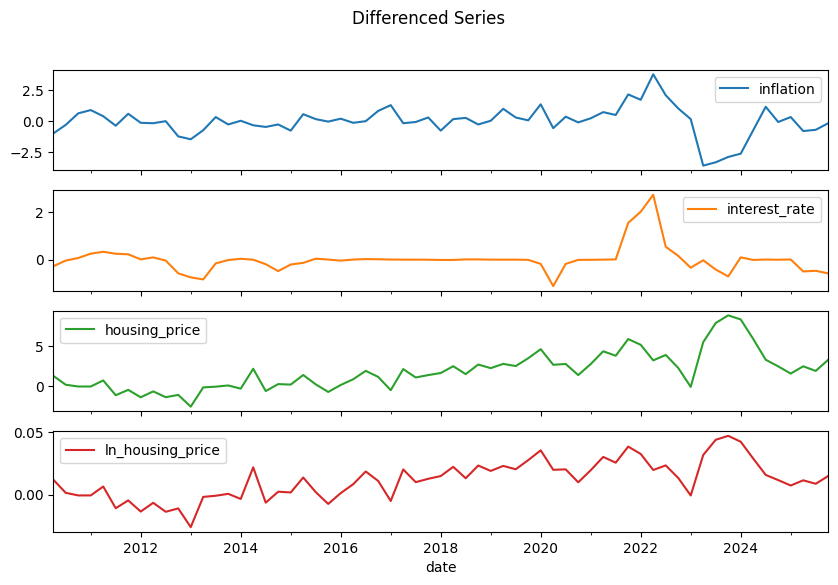

,inflation,interest_rate,housing_price,ln_housing_price
date,,,,
2010-04-01,-1.000000,-0.283333,1.27,0.012068
2010-07-01,-0.300000,-0.040000,0.15,0.001416
2010-10-01,0.633333,0.070000,-0.07,-0.000660
2011-01-01,0.900000,0.253333,-0.07,-0.000661
2011-04-01,0.400000,0.333333,0.69,0.006496


In [ ]:
df_diff = df.diff().dropna()
df_diff.plot(subplots=True, figsize=(10,6))
plt.suptitle("Differenced Series")
plt.show()

df_diff.head()

First-order differencing was applied to remove trends from the data and stabilize the series. The transformed values represent period-to-period changes, and the reduced fluctuations around zero indicate that the data is becoming more stationary.

### ADF Test again on the differenced data

In [21]:
adf_test(df_diff['inflation'], 'Inflation (diff)')
adf_test(df_diff['interest_rate'], 'Interest Rate (diff)')
adf_test(df_diff['ln_housing_price'], 'Diff Log Housing Price')

ADF Test for Inflation (diff)
ADF Statistic: -3.4501183466869567
p-value: 0.009364472562398843
--------------------------
ADF Test for Interest Rate (diff)
ADF Statistic: -3.7179585931987944
p-value: 0.00386752552718277
--------------------------
ADF Test for Diff Log Housing Price
ADF Statistic: -3.090038489552399
p-value: 0.027299221910577258
--------------------------


### Interpretation After First Differencing
- After applying first-order differencing, we performed the ADF test again to check whether the data became stationary.

- The results show that all variables now have p-values less than 0.05, which means these variables have become stationary after differencing. This indicates that differencing successfully removed trends and stabilized these series.



Having established stationarity after first differencing, we can now employ a VAR model to analyse the dynamic relationships among the variables. The VAR framework allows each variable to be explained by its own past values as well as the past values of the other variables, making it suitable for studying the interactions between inflation, interest rates, and housing prices.

### Apply VAR Model

In [27]:
from statsmodels.tsa.api import VAR

final_df = df_diff[['inflation', 'interest_rate', 'ln_housing_price']]

# Step 1: Lag selection
model = VAR(final_df)
lag_selection = model.select_order(maxlags=8)
print(lag_selection.summary())

# Step 2: Fit model using selected lag
optimal_lag = lag_selection.aic
results = model.fit(optimal_lag)

results.summary()

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -9.601      -9.491   6.768e-05      -9.558
1      -10.93     -10.49*   1.797e-05     -10.76*
2      -10.78      -10.02   2.083e-05      -10.49
3      -10.84      -9.744   1.986e-05      -10.42
4     -11.30*      -9.876  1.272e-05*      -10.75
5      -11.14      -9.387   1.531e-05      -10.46
6      -11.21      -9.128   1.482e-05      -10.40
7      -11.17      -8.762   1.623e-05      -10.24
8      -11.21      -8.473   1.678e-05      -10.15
-------------------------------------------------


C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 31, May, 2026
Time:                     14:10:51
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -9.96819
Nobs:                     59.0000    HQIC:                  -10.8054
Log likelihood:           122.421    FPE:                1.21348e-05
AIC:                     -11.3415    Det(Omega_mle):     6.67715e-06
--------------------------------------------------------------------
Results for equation inflation
                         coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------
const                      -0.136052         0.144789           -0.940           0.347
L1.inflation                0.421980         0.145338            2.903           0.004
L1.interest_rate            0.17